# Bengali VQA — MCRAN (Multimodal Cross-modal Representation Attention Network)
**Paper:** BVQA: Connecting Language and Vision Through Multimodal Attention for Open-Ended Question Answering (IEEE Access 2025)

### Folder structure created by this notebook:
```
/content/Bengali_VQA/
├── Dataset/
│   ├── Images/          ← put all .jpg/.png images here
│   ├── train.xlsx
│   ├── val.xlsx
│   └── test.xlsx
└── saved_models/        ← best model checkpoints saved here
```

**Run cells top to bottom. GPU runtime recommended (Runtime → Change runtime type → T4 GPU).**

## Cell 1 — Install dependencies

In [1]:
!pip install -q torch torchvision transformers openpyxl scikit-learn madgrad gdown nltk pandas matplotlib seaborn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Cell 2 — Download dataset from Google Drive

In [2]:
import os, gdown, zipfile

BASE_DIR   = '/content/Bengali_VQA'
DATA_DIR   = os.path.join(BASE_DIR, 'Dataset')
IMG_DIR    = os.path.join(DATA_DIR, 'Images')
MODEL_DIR  = os.path.join(BASE_DIR, 'saved_models')

for d in [BASE_DIR, DATA_DIR, IMG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)

# Official dataset from the paper
FILE_ID  = '1W88qcCy80_XnKgC-4t36WPPria1Aq5lW'
ZIP_PATH = os.path.join(BASE_DIR, 'bvqa_dataset.zip')

if not os.path.exists(ZIP_PATH):
    gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(DATA_DIR)

print('Dataset extracted. Contents:')
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    for f in files[:5]:
        print('  ' * (level+1) + f)
    if len(files) > 5:
        print('  ' * (level+1) + f'... and {len(files)-5} more')

Downloading...
From (original): https://drive.google.com/uc?id=1W88qcCy80_XnKgC-4t36WPPria1Aq5lW
From (redirected): https://drive.google.com/uc?id=1W88qcCy80_XnKgC-4t36WPPria1Aq5lW&confirm=t&uuid=e2f54f72-52e6-4f90-8d95-363e6157510a
To: /content/Bengali_VQA/bvqa_dataset.zip
100%|██████████| 2.28G/2.28G [00:28<00:00, 78.7MB/s]


Dataset extracted. Contents:
Dataset/
  Dataset/
    test_bvqa.xlsx
    valid_bvqa.xlsx
    train_bvqa.xlsx
    images/
      1435.png
      2742.png
      1607.png
      3181.png
      3293.png
      ... and 3539 more
  Images/


## Cell 3 — Imports & Config

In [6]:
import os, math, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as tv_models

from transformers import AutoTokenizer, AutoModel

# ─── CONFIG ────────────────────────────────────────────────────────────────────
BASE_DIR   = '/content/Bengali_VQA'
DATA_DIR   = os.path.join(BASE_DIR, 'Dataset')
IMG_DIR    = os.path.join(BASE_DIR, 'Dataset')
MODEL_DIR  = os.path.join(BASE_DIR, 'saved_models')

CFG = {
    'train_xlsx' : '/content/Bengali_VQA/Dataset/Dataset/train_bvqa.xlsx',
    'val_xlsx'   : '/content/Bengali_VQA/Dataset/Dataset/valid_bvqa.xlsx',
    'test_xlsx'  : '/content/Bengali_VQA/Dataset/Dataset/test_bvqa.xlsx',
    'img_dir'    : '/content/Bengali_VQA/Dataset/Dataset/images',
    'model_save' : os.path.join(MODEL_DIR, 'mcran_best.pth'),

    'text_model'  : 'bert-base-multilingual-cased',
    'max_len'     : 64,
    'img_feat_dim': 2048,
    'img_size'    : 224,
    'hidden_dim'  : 768,
    'n_heads'     : 6,
    'n_layers'    : 2,
    'dropout'     : 0.3,
    'batch_size'  : 32,
    'epochs'      : 15,
    'lr'          : 1e-5,
    'seed'        : 42,
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

Device: cuda


In [5]:
import glob

# Auto-detect actual file locations
found_xlsx = glob.glob('/content/Bengali_VQA/**/*.xlsx', recursive=True)
found_imgs = glob.glob('/content/Bengali_VQA/**/images', recursive=True)

print("Found xlsx files:", found_xlsx)
print("Found image dir:", found_imgs)

# Patch CFG
for f in found_xlsx:
    if 'train' in f: CFG['train_xlsx'] = f
    if 'valid' in f: CFG['val_xlsx']   = f
    if 'test'  in f: CFG['test_xlsx']  = f

if found_imgs:
    CFG['img_dir'] = found_imgs[0]

print("\nPatched CFG paths:")
print("  train:", CFG['train_xlsx'])
print("  val:  ", CFG['val_xlsx'])
print("  test: ", CFG['test_xlsx'])
print("  imgs: ", CFG['img_dir'])

Found xlsx files: ['/content/Bengali_VQA/Dataset/Dataset/test_bvqa.xlsx', '/content/Bengali_VQA/Dataset/Dataset/valid_bvqa.xlsx', '/content/Bengali_VQA/Dataset/Dataset/train_bvqa.xlsx']
Found image dir: ['/content/Bengali_VQA/Dataset/Dataset/images']

Patched CFG paths:
  train: /content/Bengali_VQA/Dataset/Dataset/train_bvqa.xlsx
  val:   /content/Bengali_VQA/Dataset/Dataset/valid_bvqa.xlsx
  test:  /content/Bengali_VQA/Dataset/Dataset/test_bvqa.xlsx
  imgs:  /content/Bengali_VQA/Dataset/Dataset/images


## Cell 4 — Explore & understand the dataset

In [16]:
train_df = pd.read_excel(CFG['train_xlsx'])
val_df   = pd.read_excel(CFG['val_xlsx'])
test_df  = pd.read_excel(CFG['test_xlsx'])

print('Train:', train_df.shape, '| Val:', val_df.shape, '| Test:', test_df.shape)
print('\nColumns:', train_df.columns.tolist())
display(train_df.head(3))

# enc_answers is already an integer index (0–139)
# just map each integer → the actual Bengali answer string
NUM_CLASSES = train_df['enc_answers'].nunique()

# build mapping: integer code → Bengali answer text
code_to_answer = (
    train_df[['enc_answers', 'answers']]
    .drop_duplicates('enc_answers')
    .set_index('enc_answers')['answers']
    .to_dict()
)
idx2answer = code_to_answer          # code IS the idx
answer2idx = {v: k for k, v in code_to_answer.items()}

print(f'\nNumber of answer classes: {NUM_CLASSES}')
print('Category distribution:')
print(train_df['category'].value_counts())
print('\nSample mapping (code → answer):')
for k in sorted(list(code_to_answer.keys()))[:8]:
    print(f'  {k} → {code_to_answer[k]}')

Train: (9557, 5) | Val: (720, 5) | Test: (774, 5)

Columns: ['filename', 'questions', 'answers', 'enc_answers', 'category']


,filename,questions,answers,enc_answers,category
0,1899.png,শিশুটি কার পাশে দাড়িয়ে আছে,নারীর,54,other
1,677.png,কে লাফ দিচ্ছে,মানুষ,4,other
2,783.png,কে যাচ্ছে,মানুষ,4,other



Number of answer classes: 140
Category distribution:
category
other       4701
counting    3900
yes/no       956
Name: count, dtype: int64

Sample mapping (code → answer):
  0 → হ্যাঁ
  1 → কয়েকজন
  2 → পুরুষ
  3 → নারী
  4 → মানুষ
  5 → দুইজন
  6 → একজন
  7 → দুই


## Cell 5 — Dataset & DataLoader

In [17]:
class BVQADataset(Dataset):
    """Bengali VQA Dataset.
    Expected xlsx columns: filename, questions, enc_answers, category
    """
    def __init__(self, df, img_dir, tokenizer, answer2idx, max_len=64,
                 img_size=224, is_test=False):
        self.df         = df.reset_index(drop=True)
        self.img_dir    = img_dir
        self.tokenizer  = tokenizer
        self.answer2idx = answer2idx
        self.max_len    = max_len
        self.is_test    = is_test

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406],
                                 std =[0.229,0.224,0.225]),
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── image ──────────────────────────────────────────────────────────
        img_path = os.path.join(self.img_dir, row['filename'])
        try:
            image = Image.open(img_path).convert('RGB')
        except FileNotFoundError:
            image = Image.new('RGB', (224, 224), (0, 0, 0))
        image = self.transform(image)

        # ── question ───────────────────────────────────────────────────────
        question = str(row['questions'])
        enc = self.tokenizer(
            question,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        # ── label ──────────────────────────────────────────────────────────
        label = -1
        if not self.is_test:
            ans = str(row['enc_answers'])
            # NEW (correct) — enc_answers is already the integer label
            label = int(row['enc_answers'])

        return {
            'image'         : image,
            'input_ids'     : input_ids,
            'attention_mask': attention_mask,
            'label'         : torch.tensor(label, dtype=torch.long),
            'category'      : str(row.get('category', 'other')),
        }


# ── Tokenizer ────────────────────────────────────────────────────────────────
print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(CFG['text_model'])

train_ds = BVQADataset(train_df, CFG['img_dir'], tokenizer, answer2idx,
                       CFG['max_len'], CFG['img_size'])
val_ds   = BVQADataset(val_df,   CFG['img_dir'], tokenizer, answer2idx,
                       CFG['max_len'], CFG['img_size'])
test_ds  = BVQADataset(test_df,  CFG['img_dir'], tokenizer, answer2idx,
                       CFG['max_len'], CFG['img_size'], is_test=True)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Loading tokenizer...
Train batches: 299 | Val: 23 | Test: 25


## Cell 6 — MCRAN Model Architecture

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  Image Encoder  (ResNet-50, last FC removed → spatial feature map)
# ─────────────────────────────────────────────────────────────────────────────
class ImageEncoder(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        backbone = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
        # keep up to avgpool → output shape (B, 2048, 1, 1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.proj     = nn.Linear(2048, hidden_dim)
        self.norm     = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        feat = self.features(x).flatten(1)   # (B, 2048)
        feat = self.norm(self.proj(feat))     # (B, H)
        return feat.unsqueeze(1)              # (B, 1, H)  — single visual token


# ─────────────────────────────────────────────────────────────────────────────
#  Text Encoder  (mBERT)
# ─────────────────────────────────────────────────────────────────────────────
class TextEncoder(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        # freeze lower layers for efficiency
        for layer in self.bert.encoder.layer[:8]:
            for p in layer.parameters():
                p.requires_grad = False

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # last_hidden_state: (B, seq_len, 768)
        return out.last_hidden_state


# ─────────────────────────────────────────────────────────────────────────────
#  Cross-Modal Attention Block
#  Produces ICAR and TCAR as described in the paper
# ─────────────────────────────────────────────────────────────────────────────
class CrossModalAttention(nn.Module):
    """query attends to key/value."""
    def __init__(self, hidden_dim, n_heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, query, kv, key_padding_mask=None):
        out, _ = self.attn(query, kv, kv,
                           key_padding_mask=key_padding_mask)
        return self.norm(query + self.drop(out))


# ─────────────────────────────────────────────────────────────────────────────
#  Token-level Multimodal Attention (MMAR)
# ─────────────────────────────────────────────────────────────────────────────
class MultimodalAttentionLayer(nn.Module):
    def __init__(self, hidden_dim, n_heads, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.ffn  = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 4, hidden_dim),
        )
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        a, _ = self.self_attn(x, x, x, key_padding_mask=padding_mask)
        x = self.norm1(x + self.drop(a))
        x = self.norm2(x + self.drop(self.ffn(x)))
        return x


# ─────────────────────────────────────────────────────────────────────────────
#  MCRAN — full model
# ─────────────────────────────────────────────────────────────────────────────
class MCRAN(nn.Module):
    """
    Multimodal Cross-modal Representation Attention Network

    Three branches:
      ICAR  – image queries text  (Image-weighted Cross-modal)
      TCAR  – text  queries image (Text-weighted Cross-modal)
      MMAR  – joint token sequence self-attention

    Fused via learned gating → classifier.
    """
    def __init__(self, num_classes, hidden_dim=768,
                 n_heads=6, n_layers=2, dropout=0.3,
                 text_model='bert-base-multilingual-cased'):
        super().__init__()
        self.img_enc  = ImageEncoder(hidden_dim)
        self.txt_enc  = TextEncoder(text_model)

        # Cross-modal: ICAR branch (image ← text)
        self.icar_layers = nn.ModuleList([
            CrossModalAttention(hidden_dim, n_heads, dropout)
            for _ in range(n_layers)
        ])
        # Cross-modal: TCAR branch (text ← image)
        self.tcar_layers = nn.ModuleList([
            CrossModalAttention(hidden_dim, n_heads, dropout)
            for _ in range(n_layers)
        ])
        # Token-level joint attention: MMAR
        self.mmar_layers = nn.ModuleList([
            MultimodalAttentionLayer(hidden_dim, n_heads, dropout)
            for _ in range(n_layers)
        ])

        # Gating mechanism (3-way soft gate)
        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 3, 3),
            nn.Softmax(dim=-1)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

        self.drop = nn.Dropout(dropout)

    def forward(self, images, input_ids, attention_mask):
        # ── Encode ─────────────────────────────────────────────────────────
        img_feat  = self.img_enc(images)          # (B, 1, H)
        txt_feat  = self.txt_enc(input_ids,        # (B, L, H)
                                  attention_mask)

        txt_pad_mask = (attention_mask == 0)       # True where padding

        # ── ICAR: image attends to text ────────────────────────────────────
        icar = img_feat
        for layer in self.icar_layers:
            icar = layer(icar, txt_feat, key_padding_mask=txt_pad_mask)
        icar_vec = icar.squeeze(1)                # (B, H)

        # ── TCAR: text attends to image ────────────────────────────────────
        tcar = txt_feat
        for layer in self.tcar_layers:
            tcar = layer(tcar, img_feat)          # image has no padding
        # pool over text sequence (mean of non-padding tokens)
        mask_exp   = attention_mask.unsqueeze(-1).float()  # (B, L, 1)
        tcar_vec   = (tcar * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1)

        # ── MMAR: joint self-attention over concatenated tokens ────────────
        # concat image + text tokens
        img_mask   = torch.zeros(images.size(0), 1,
                                  device=images.device, dtype=torch.bool)
        joint_seq  = torch.cat([img_feat, txt_feat], dim=1)  # (B, 1+L, H)
        joint_mask = torch.cat([img_mask, txt_pad_mask], dim=1)
        for layer in self.mmar_layers:
            joint_seq = layer(joint_seq, padding_mask=joint_mask)
        mmar_vec = joint_seq[:, 0, :]             # CLS = image token (B, H)

        # ── Gating fusion ──────────────────────────────────────────────────
        concat_all = torch.cat([icar_vec, tcar_vec, mmar_vec], dim=-1)  # (B, 3H)
        gates      = self.gate(concat_all)        # (B, 3)

        fused = (gates[:, 0:1] * icar_vec +
                 gates[:, 1:2] * tcar_vec +
                 gates[:, 2:3] * mmar_vec)        # (B, H)

        logits = self.classifier(self.drop(fused))
        return logits


# ── Instantiate ───────────────────────────────────────────────────────────────
print('Building MCRAN model...')
model = MCRAN(
    num_classes = NUM_CLASSES,
    hidden_dim  = CFG['hidden_dim'],
    n_heads     = CFG['n_heads'],
    n_layers    = CFG['n_layers'],
    dropout     = CFG['dropout'],
    text_model  = CFG['text_model']
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Building MCRAN model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable parameters: 170,221,135


## Cell 7 — Loss, Optimizer, Scheduler

In [19]:
from madgrad import MADGRAD

criterion = nn.CrossEntropyLoss()
optimizer = MADGRAD(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-7
)
print('Optimizer and scheduler ready.')

Optimizer and scheduler ready.


## Cell 8 — Training & Validation Functions

In [20]:
def run_epoch(model, loader, criterion, optimizer=None, desc='Train'):
    """One pass over a DataLoader.  optimizer=None → eval mode."""
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels, all_cats = 0.0, [], [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            images   = batch['image'].to(DEVICE)
            ids      = batch['input_ids'].to(DEVICE)
            mask     = batch['attention_mask'].to(DEVICE)
            labels   = batch['label'].to(DEVICE)
            cats     = batch['category']

            logits = model(images, ids, mask)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_cats.extend(cats)

    n    = len(all_labels)
    loss = total_loss / n
    acc  = accuracy_score(all_labels, all_preds)

    # Per-category accuracy
    cat_acc = {}
    for cat in set(all_cats):
        idxs = [i for i, c in enumerate(all_cats) if c == cat]
        cat_acc[cat] = accuracy_score(
            [all_labels[i] for i in idxs],
            [all_preds[i]  for i in idxs]
        )

    return loss, acc, cat_acc


print('Training functions defined.')

Training functions defined.


In [21]:
# ── DEBUG CELL ─────────────────────────────────────────────────────────────────
train_df = pd.read_excel(CFG['train_xlsx'])
val_df   = pd.read_excel(CFG['val_xlsx'])
test_df  = pd.read_excel(CFG['test_xlsx'])

print("=== Column names ===")
print(train_df.columns.tolist())

print("\n=== First 5 rows ===")
print(train_df.head())

print("\n=== enc_answers sample ===")
print(train_df['enc_answers'].value_counts().head(20))

print("\n=== How many unique enc_answers? ===")
print(train_df['enc_answers'].nunique())

print("\n=== category distribution ===")
print(train_df['category'].value_counts())

print("\n=== answers sample (raw) ===")
print(train_df['answers'].value_counts().head(20))

=== Column names ===
['filename', 'questions', 'answers', 'enc_answers', 'category']

=== First 5 rows ===
   filename                    questions answers  enc_answers  category
0  1899.png  শিশুটি কার পাশে দাড়িয়ে আছে    নারীর           54     other
1   677.png               কে লাফ দিচ্ছে    মানুষ            4     other
2   783.png                   কে যাচ্ছে    মানুষ            4     other
3  3422.png          কতজন পুরুষ বসে আছে      তিন           12  counting
4  3123.png           মঞ্চের উপর কে আছে    মানুষ            4     other

=== enc_answers sample ===
enc_answers
0     875
1     740
2     694
3     630
4     573
5     353
6     326
7     294
8     292
9     275
10    264
11    199
12    167
13    157
14    140
15    120
16    119
17    106
18    101
19     90
Name: count, dtype: int64

=== How many unique enc_answers? ===
140

=== category distribution ===
category
other       4701
counting    3900
yes/no       956
Name: count, dtype: int64

=== answers sample (raw) ===
answer

## Cell 9 — Training Loop

In [23]:
!pip install -q tqdm

from tqdm.notebook import tqdm

def run_epoch(model, loader, criterion, optimizer=None, desc='Train'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, all_preds, all_labels, all_cats = 0.0, [], [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=True)
        for batch in pbar:
            images   = batch['image'].to(DEVICE)
            ids      = batch['input_ids'].to(DEVICE)
            mask     = batch['attention_mask'].to(DEVICE)
            labels   = batch['label'].to(DEVICE)
            cats     = batch['category']

            logits = model(images, ids, mask)
            loss   = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_cats.extend(cats)

            # live loss update inside the bar
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    n    = len(all_labels)
    loss = total_loss / n
    acc  = accuracy_score(all_labels, all_preds)

    cat_acc = {}
    for cat in set(all_cats):
        idxs = [i for i, c in enumerate(all_cats) if c == cat]
        cat_acc[cat] = accuracy_score(
            [all_labels[i] for i in idxs],
            [all_preds[i]  for i in idxs]
        )

    return loss, acc, cat_acc


history = {'train_loss': [], 'train_acc': [],
           'val_loss'  : [], 'val_acc'  : []}

best_val_acc = 0.0

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()

    print(f'\n─── Epoch {epoch}/{CFG["epochs"]} ───')
    tr_loss, tr_acc, _       = run_epoch(model, train_loader, criterion, optimizer, desc='  Train')
    vl_loss, vl_acc, vl_cat  = run_epoch(model, val_loader,   criterion,            desc='  Val  ')
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    elapsed = time.time() - t0
    print(f'  loss  train={tr_loss:.4f}  val={vl_loss:.4f}')
    print(f'  acc   train={tr_acc:.4f}  val={vl_acc:.4f}   [{elapsed:.0f}s]')
    print(f'  category acc: {vl_cat}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), CFG['model_save'])
        print(f'  ✓ Best model saved  (val_acc={best_val_acc:.4f})')

print(f'\nDone. Best val accuracy: {best_val_acc:.4f}')


─── Epoch 1/15 ───


  Train:   0%|          | 0/299 [00:00<?, ?it/s]

  Val  :   0%|          | 0/23 [00:00<?, ?it/s]

  loss  train=3.7822  val=3.0244
  acc   train=0.2012  val=0.3181   [297s]
  category acc: {'other': 0.2563380281690141, 'counting': 0.2525597269624573, 'yes/no': 0.8888888888888888}
  ✓ Best model saved  (val_acc=0.3181)

─── Epoch 2/15 ───


  Train:   0%|          | 0/299 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/23 [00:00<?, ?it/s]

  loss  train=0.5521  val=1.6771
  acc   train=0.8541  val=0.6264   [257s]
  category acc: {'other': 0.6450704225352113, 'counting': 0.5631399317406144, 'yes/no': 0.7916666666666666}

─── Epoch 15/15 ───


  Train:   0%|          | 0/299 [00:00<?, ?it/s]

  Val  :   0%|          | 0/23 [00:00<?, ?it/s]

  loss  train=0.5212  val=1.6637
  acc   train=0.8639  val=0.6375   [257s]
  category acc: {'other': 0.6591549295774648, 'counting': 0.5699658703071673, 'yes/no': 0.8055555555555556}

Done. Best val accuracy: 0.6375


## Cell 10 — Plot Training Curves

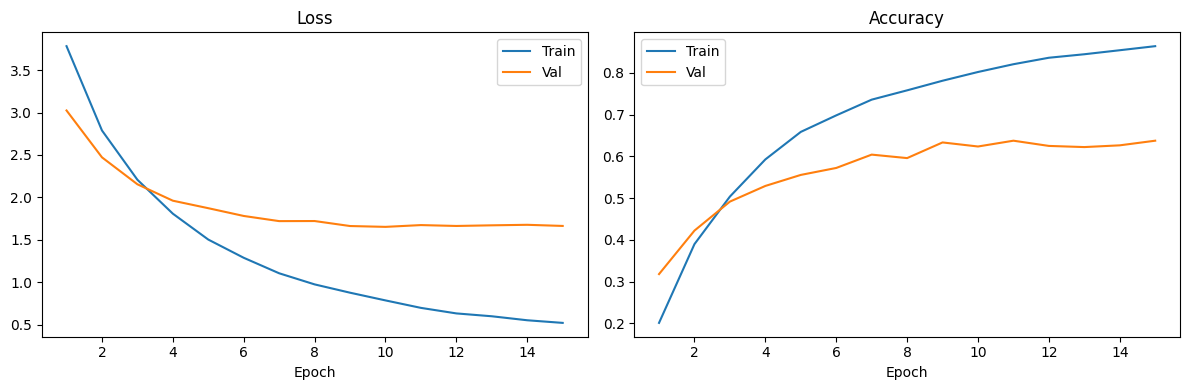

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, CFG['epochs'] + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'training_curves.png'), dpi=150)
plt.show()

## Cell 11 — Evaluate on Test Set

In [26]:
# Load best weights
model.load_state_dict(torch.load(CFG['model_save'], map_location=DEVICE))
model.eval()

all_preds, all_labels, all_cats = [], [], []

with torch.no_grad():
    for batch in test_loader:
        images = batch['image'].to(DEVICE)
        ids    = batch['input_ids'].to(DEVICE)
        mask   = batch['attention_mask'].to(DEVICE)
        cats   = batch['category']

        logits = model(images, ids, mask)
        preds  = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_cats.extend(cats)

# Get true labels directly from the dataframe (enc_answers IS the label)
all_labels = test_df['enc_answers'].tolist()

# Overall accuracy
overall_acc = accuracy_score(all_labels, all_preds)
print(f'Overall Test Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)')

# Per-category accuracy
print('\nPer-category accuracy:')
test_cats = test_df['category'].tolist()
for cat in sorted(set(test_cats)):
    idxs = [i for i, c in enumerate(test_cats) if c == cat]
    cat_acc = accuracy_score(
        [all_labels[i] for i in idxs],
        [all_preds[i]  for i in idxs]
    )
    print(f'  {cat:12s}: {cat_acc:.4f}  ({len(idxs)} samples)')

Overall Test Accuracy: 0.6460 (64.60%)

Per-category accuracy:
  counting    : 0.5623  (313 samples)
  other       : 0.6693  (384 samples)
  yes/no      : 0.8701  (77 samples)


## Cell 12 — Inference on a Single Image + Question

/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Glyph 2478 (\N{BENGALI LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Glyph 2494 (\N{BENGALI VOWEL SIGN AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Glyph 2497 (\N{BENGALI VOWEL SIGN U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Glyph 2487 (\N{BENGALI LETTER SSA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1135935401.py:32: UserWarning: Glyph 2455 (\N{BENGALI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215

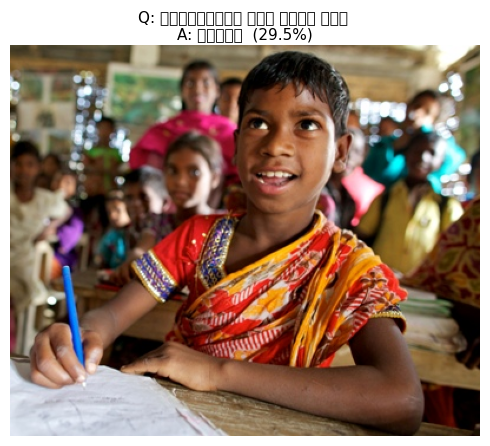

Predicted: পিছনে  |  Confidence: 0.295
Ground truth: 64


In [27]:
def predict(image_path, question, model, tokenizer, answer2idx, idx2answer,
            device=DEVICE, max_len=64, img_size=224):
    """Run a single Bengali VQA inference."""
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

    img = Image.open(image_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)

    enc = tokenizer(question, max_length=max_len, padding='max_length',
                    truncation=True, return_tensors='pt')
    ids  = enc['input_ids'].to(device)
    mask = enc['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        logits = model(img_t, ids, mask)
        probs  = torch.softmax(logits, dim=-1)
        pred   = logits.argmax(dim=-1).item()

    answer     = idx2answer[pred]
    confidence = probs[0, pred].item()

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.set_title(f'Q: {question}\nA: {answer}  ({confidence*100:.1f}%)',
                 fontsize=11, wrap=True)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    return answer, confidence


# ── Demo: pick any test sample ─────────────────────────────────────────────────
sample      = test_df.iloc[0]
sample_path = os.path.join(CFG['img_dir'], sample['filename'])
sample_q    = sample['questions']

answer, conf = predict(sample_path, sample_q, model, tokenizer,
                       answer2idx, idx2answer)
print(f'Predicted: {answer}  |  Confidence: {conf:.3f}')
if 'enc_answers' in sample:
    print(f'Ground truth: {sample["enc_answers"]}')

## Cell 13 — (Optional) Ablation: different image encoders

In [29]:
# Run this cell only if you want to ablate image encoders

class ImageEncoderVariant(nn.Module):
    """Supports resnet50 | convnext_base | efficientnet_b0."""
    def __init__(self, backbone_name, hidden_dim):
        super().__init__()
        if backbone_name == 'resnet50':
            bb = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
            self.body   = nn.Sequential(*list(bb.children())[:-1])
            feat_dim    = 2048
        elif backbone_name == 'convnext_base':
            bb = tv_models.convnext_base(weights=tv_models.ConvNeXt_Base_Weights.IMAGENET1K_V1)
            self.body   = nn.Sequential(bb.features, bb.avgpool)
            feat_dim    = 1024
        elif backbone_name == 'efficientnet_b0':
            bb = tv_models.efficientnet_b0(weights=tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            self.body   = nn.Sequential(bb.features, bb.avgpool)
            feat_dim    = 1280
        else:
            raise ValueError(backbone_name)

        self.proj = nn.Linear(feat_dim, hidden_dim)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        feat = self.body(x).flatten(1)
        return self.norm(self.proj(feat)).unsqueeze(1)


print('ImageEncoderVariant class defined. Swap into MCRAN to run ablation.')
print('Backbone options: resnet50 | convnext_base | efficientnet_b0')

ImageEncoderVariant class defined. Swap into MCRAN to run ablation.
Backbone options: resnet50 | convnext_base | efficientnet_b0


## Cell 14 — Save predictions CSV

In [28]:
results = test_df.copy()
results['predicted_answer'] = [idx2answer[p] for p in all_preds]
results['correct'] = (
    results['enc_answers'].astype(str) == results['predicted_answer'].astype(str)
)

out_csv = os.path.join(BASE_DIR, 'test_predictions.csv')
results.to_csv(out_csv, index=False)
print(f'Predictions saved to {out_csv}')
display(results.head(5))

Predictions saved to /content/Bengali_VQA/test_predictions.csv


,filename,questions,answers,enc_answers,category,predicted_answer,correct
0,1625.png,মানুষগুলো কোন দিকে আছে,পিছনে,64,other,পিছনে,False
1,204.png,মহিলারা কোথায় কাজ করছে,মাঠে,72,other,রাস্তায়,False
2,1678.png,কতজন নারী আছে,দুই,7,counting,একজন,False
3,2327.png,লোকটি কি হাতে ধরে করছে,রঙ,90,other,রঙ,False
4,2842.png,কতটি ছেলে শিশু চোখে চশমা পরে আছে,দুইটি,31,counting,দুইটি,False


Step 1: Upload an image


Saving qa2.jpg to qa2.jpg
✓ Uploaded: qa2.jpg

Step 2: Type your question in Bengali and press Enter
Question (Bengali): নৌকায় মোট কতজন মানুষ আছে?


/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Glyph 2474 (\N{BENGALI LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Glyph 2509 (\N{BENGALI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Glyph 2480 (\N{BENGALI LETTER RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Glyph 2486 (\N{BENGALI LETTER SHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Glyph 2472 (\N{BENGALI LETTER NA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/1927693607.py:48: UserWarning: Glyph 2508 (\N{BENGALI VOWEL SIGN AU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155

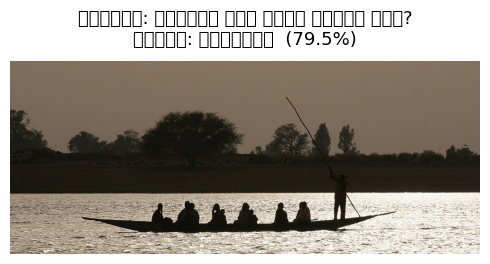


Question  : নৌকায় মোট কতজন মানুষ আছে?
Answer    : কয়েকজন
Confidence: 79.5%

Top 5 possible answers:
  1. কয়েকজন          79.5%
  2. অনেকগুলো         4.9%
  3. তিনজন            3.7%
  4. দুই              3.2%
  5. পাঁচজন           1.1%


In [34]:
from google.colab import files
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

# ── Upload image ──────────────────────────────────────────────────────────────
print("Step 1: Upload an image")
uploaded = files.upload()
img_filename = list(uploaded.keys())[0]
print(f"✓ Uploaded: {img_filename}")

# ── Question input ────────────────────────────────────────────────────────────
print("\nStep 2: Type your question in Bengali and press Enter")
question = input("Question (Bengali): ")

# ── Run prediction ────────────────────────────────────────────────────────────
model.load_state_dict(torch.load(CFG['model_save'], map_location=DEVICE))
model.eval()

transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

img = Image.open(img_filename).convert('RGB')
img_t = transform(img).unsqueeze(0).to(DEVICE)

enc  = tokenizer(question, max_length=CFG['max_len'], padding='max_length',
                 truncation=True, return_tensors='pt')
ids  = enc['input_ids'].to(DEVICE)
mask = enc['attention_mask'].to(DEVICE)

with torch.no_grad():
    logits = model(img_t, ids, mask)
    probs  = torch.softmax(logits, dim=-1)
    pred   = logits.argmax(dim=-1).item()

answer     = idx2answer[pred]
confidence = probs[0, pred].item()

# ── Show result ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img)
ax.set_title(f'প্রশ্ন: {question}\nউত্তর: {answer}  ({confidence*100:.1f}%)',
             fontsize=13, pad=12)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f'\nQuestion  : {question}')
print(f'Answer    : {answer}')
print(f'Confidence: {confidence*100:.1f}%')

# ── Top 5 predictions ─────────────────────────────────────────────────────────
print('\nTop 5 possible answers:')
top5 = probs[0].topk(5)
for rank, (score, idx) in enumerate(zip(top5.values, top5.indices), 1):
    print(f'  {rank}. {idx2answer[idx.item()]:15s}  {score.item()*100:.1f}%')

In [31]:
# ── Show random test samples with predictions ─────────────────────────────────
import math

model.load_state_dict(torch.load(CFG['model_save'], map_location=DEVICE))
model.eval()

# Pick 20 random samples from test set
samples = test_df.sample(20, random_state=42).reset_index(drop=True)

correct_samples = []
wrong_samples   = []

transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

for _, row in samples.iterrows():
    img_path = os.path.join(CFG['img_dir'], row['filename'])
    img = Image.open(img_path).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(DEVICE)

    enc  = tokenizer(str(row['questions']), max_length=CFG['max_len'],
                     padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(img_t, enc['input_ids'].to(DEVICE),
                       enc['attention_mask'].to(DEVICE))
        pred = logits.argmax(dim=-1).item()

    predicted = idx2answer[pred]
    actual    = row['answers']
    is_correct = (str(pred) == str(row['enc_answers']))

    if is_correct:
        correct_samples.append(row)
    else:
        wrong_samples.append(row)

print(f"Out of 20 random samples — Correct: {len(correct_samples)} | Wrong: {len(wrong_samples)}")

Out of 20 random samples — Correct: 17 | Wrong: 3


Total correct: 500 / 774

By category:
category
other       257
counting    176
yes/no       67
Name: count, dtype: int64

Most common correctly predicted answers:
actual
হ্যাঁ       66
কয়েকজন     48
পুরুষ       48
নারী        37
মানুষ       34
অনেকগুলো    19
শিশু        18
দুইজন       13
তিনজন       11
একজন        11
ভালো        11
দুই         10
চারজন        7
কয়েকটি      7
তিন          7
Name: count, dtype: int64


/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Glyph 2453 (\N{BENGALI LETTER KA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Matplotlib currently does not support Bengali natively.
  plt.tight_layout()
/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Glyph 2503 (\N{BENGALI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Glyph 2482 (\N{BENGALI LETTER LA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Glyph 2495 (\N{BENGALI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Glyph 2454 (\N{BENGALI LETTER KHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2155/3864520686.py:67: UserWarning: Glyph 2459 (\N{BENGALI LETTER CHA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215

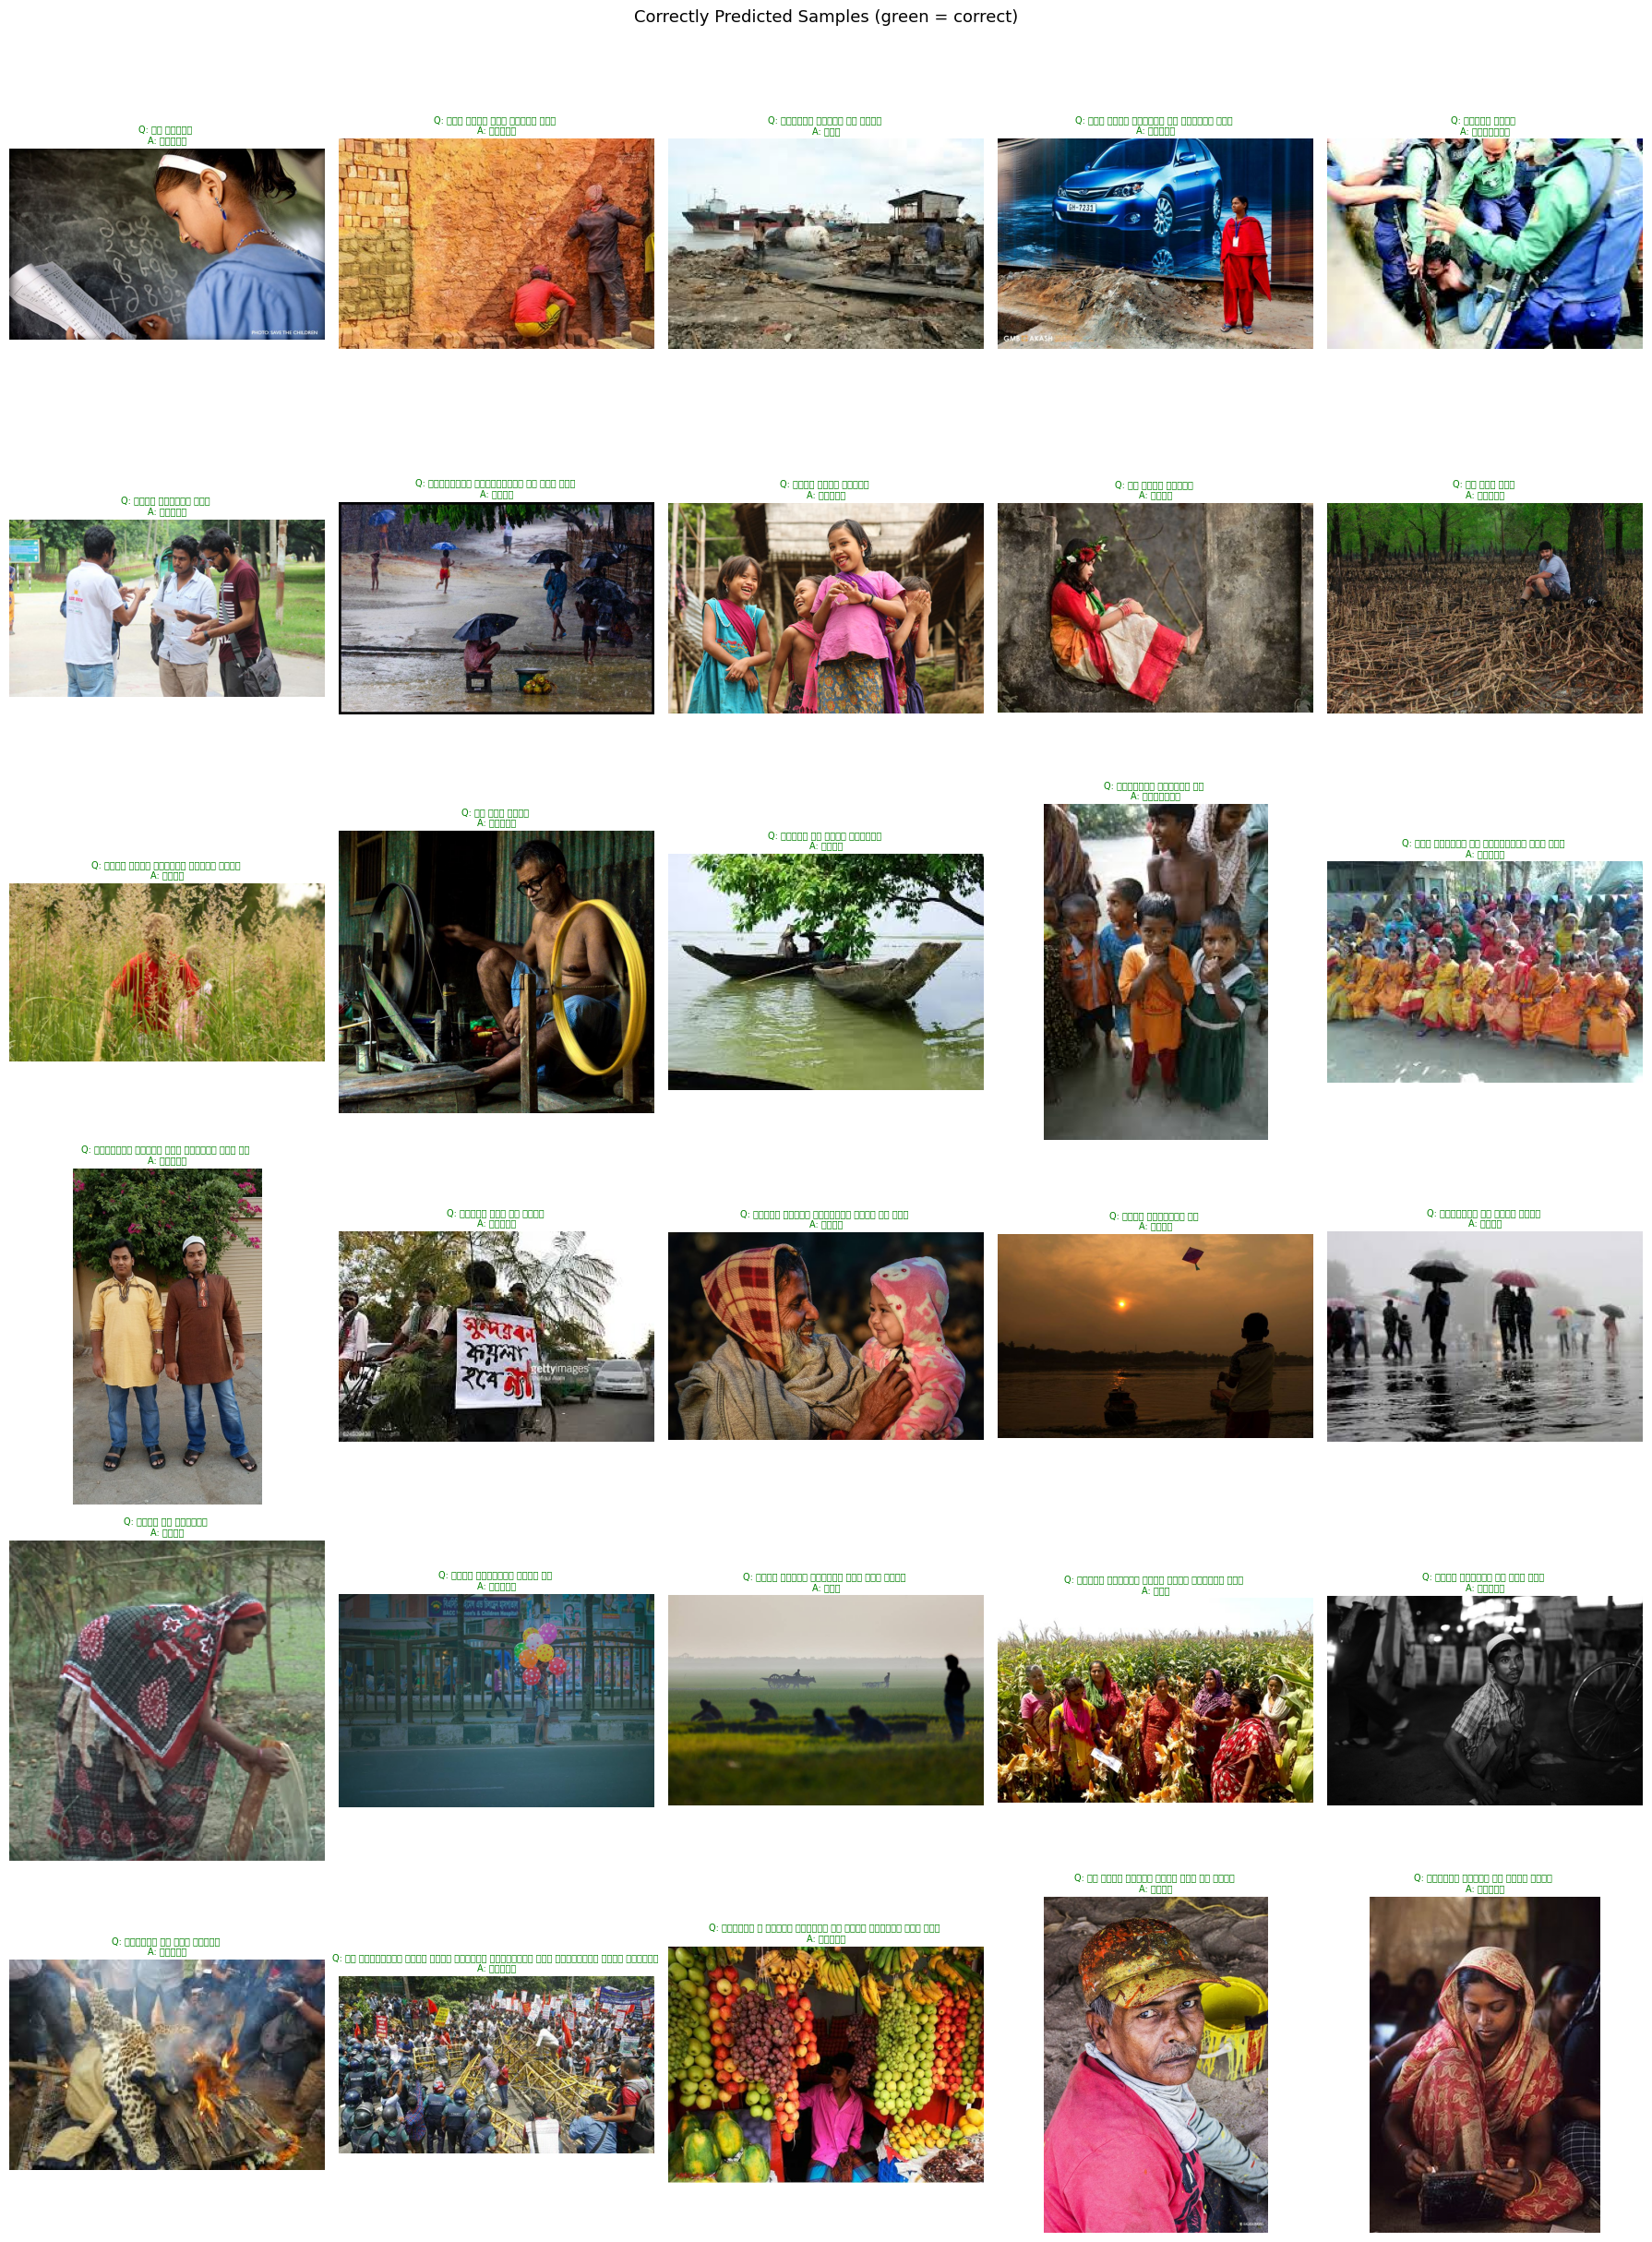

Grid saved to /content/Bengali_VQA/correct_predictions_grid.png


In [32]:
# ── Find ALL correctly predicted test samples and display them ────────────────
model.load_state_dict(torch.load(CFG['model_save'], map_location=DEVICE))
model.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

results = []

for _, row in test_df.iterrows():
    img_path = os.path.join(CFG['img_dir'], row['filename'])
    try:
        img   = Image.open(img_path).convert('RGB')
    except:
        continue
    img_t = transform(img).unsqueeze(0).to(DEVICE)

    enc = tokenizer(str(row['questions']), max_length=CFG['max_len'],
                    padding='max_length', truncation=True, return_tensors='pt')
    with torch.no_grad():
        logits = model(img_t, enc['input_ids'].to(DEVICE),
                       enc['attention_mask'].to(DEVICE))
        pred = logits.argmax(dim=-1).item()

    results.append({
        'filename' : row['filename'],
        'question' : row['questions'],
        'actual'   : row['answers'],
        'predicted': idx2answer[pred],
        'correct'  : pred == int(row['enc_answers']),
        'category' : row['category'],
    })

results_df = pd.DataFrame(results)
correct_df = results_df[results_df['correct'] == True].reset_index(drop=True)
print(f"Total correct: {len(correct_df)} / {len(results_df)}")
print(f"\nBy category:")
print(correct_df['category'].value_counts())
print(f"\nMost common correctly predicted answers:")
print(correct_df['actual'].value_counts().head(15))

# ── Display 30 correct samples as a grid ─────────────────────────────────────
show_df = correct_df.sample(min(30, len(correct_df)), random_state=1).reset_index(drop=True)

cols = 5
rows = math.ceil(len(show_df) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()

for i, row in show_df.iterrows():
    img_path = os.path.join(CFG['img_dir'], row['filename'])
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    axes[i].set_title(
        f"Q: {row['question']}\nA: {row['actual']}",
        fontsize=7, pad=4, color='green'
    )
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Correctly Predicted Samples (green = correct)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('/content/Bengali_VQA/correct_predictions_grid.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grid saved to /content/Bengali_VQA/correct_predictions_grid.png")

In [33]:
# ── Print all correct samples neatly for manual reference ────────────────────
print("=" * 70)
print(f"ALL CORRECTLY PREDICTED SAMPLES ({len(correct_df)} total)")
print("=" * 70)

for cat in ['yes/no', 'counting', 'other']:
    cat_df = correct_df[correct_df['category'] == cat]
    print(f"\n{'─'*70}")
    print(f"  CATEGORY: {cat.upper()}  ({len(cat_df)} correct)")
    print(f"{'─'*70}")
    for _, row in cat_df.head(20).iterrows():   # show top 20 per category
        print(f"  File : {row['filename']}")
        print(f"  Q    : {row['question']}")
        print(f"  A    : {row['actual']}")
        print()

ALL CORRECTLY PREDICTED SAMPLES (500 total)

──────────────────────────────────────────────────────────────────────
  CATEGORY: YES/NO  (67 correct)
──────────────────────────────────────────────────────────────────────
  File : 2735.png
  Q    : কয়েকজন মানুষ আছে কি 
  A    : হ্যাঁ

  File : 1918.png
  Q    : নারীটি কি মালা পরেছে 
  A    : হ্যাঁ

  File : 2059.png
  Q    : মহিলাটি কি কিছু শাক ধারণ করছে 
  A    : হ্যাঁ

  File : 3409.png
  Q    : বালক কি দাড়িয়ে আছে 
  A    : হ্যাঁ

  File : 2704.png
  Q    : পুরুষটি কি মাথায় সবজি ভর্তি করছে 
  A    : হ্যাঁ

  File : 3256.png
  Q    : কেউ আছে কি 
  A    : হ্যাঁ

  File : 1680.png
  Q    : কয়েকজন পুরুষ ও নারী দাড়িয়ে আছে কি 
  A    : হ্যাঁ

  File : 1052.png
  Q    : নারী কি রঙ মেখে আছে 
  A    : হ্যাঁ

  File : 3288.png
  Q    : মানুষ  কি আছে 
  A    : হ্যাঁ

  File : 441.png
  Q    : বালিকাটি কোমরে কী ধান গাছ নিয়ে আছে 
  A    : হ্যাঁ

  File : 1321.png
  Q    : বয়স্ক কি না 
  A    : হ্যাঁ

  File : 524.png
  Q    : কয়েকজন পুরুষ আছে কি 
 